<a href="https://colab.research.google.com/github/KaletaMan/Bezpiecze-stwo-AI/blob/main/lab2/BSSI_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
class CIFARModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # features.0
            nn.BatchNorm2d(32),                           # features.1
            nn.ReLU(inplace=True),                        # features.2
            nn.MaxPool2d(2),                              # features.3

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # features.4
            nn.BatchNorm2d(64),                           # features.5
            nn.ReLU(inplace=True),                        # features.6
            nn.MaxPool2d(2),                              # features.7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# features.8
            nn.BatchNorm2d(128),                          # features.9
            nn.ReLU(inplace=True),                        # features.10
            nn.MaxPool2d(2),                              # features.11
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),                              # classifier.0
            nn.Linear(128 * 4 * 4, 256),                  # classifier.1
            nn.ReLU(inplace=True),                        # classifier.2
            nn.Dropout(0.5),                              # classifier.3
            nn.Linear(256, 10)                            # classifier.4
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [5]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

def make_resnet18_cifar(num_classes=10):
    model = resnet18(weights=None)

    model.conv1 = nn.Conv2d(
        3, 64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    model.maxpool = nn.Identity()

    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

In [55]:
model = make_resnet18_cifar(num_classes=10)
model.load_state_dict(torch.load("YellowSupremeModel.pth", map_location=device))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [56]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

transform = transforms.ToTensor()

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

In [57]:
x, y = next(iter(test_loader))
x, y = x.to(device), y.to(device)

with torch.no_grad():
    output = model(x)
    pred = torch.argmax(output, dim=1)

print(f"True label: {y.item()} ({classes[y.item()]})")
print(f"Prediction: {pred.item()} ({classes[pred.item()]})")

True label: 9 (truck)
Prediction: 9 (truck)


In [58]:
import torch
import torch.nn.functional as F

def fgsm_untargeted(model, x, y_true, epsilon):
    x_adv = x.clone().detach().requires_grad_(True)

    output = model(x_adv)
    loss = F.cross_entropy(output, y_true)

    model.zero_grad()
    loss.backward()

    x_adv = x_adv + epsilon * x_adv.grad.sign()
    x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach()

In [59]:
def fgsm_targeted(model, x, y_target, epsilon):
    x_adv = x.clone().detach().requires_grad_(True)

    output = model(x_adv)
    loss = F.cross_entropy(output, y_target)

    model.zero_grad()
    loss.backward()

    x_adv = x_adv - epsilon * x_adv.grad.sign()
    x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach()

In [60]:
for x, y in test_loader:
    x, y = x.to(device), y.to(device)

    with torch.no_grad():
        pred = model(x).argmax(dim=1)

    if pred.item() == y.item():
        break

print("True label:", classes[y.item()])
print("Prediction before attack:", classes[pred.item()])

True label: frog
Prediction before attack: frog


In [62]:
target_class = torch.tensor([5], device=device)  # dog
print("Target class:", classes[target_class.item()])

Target class: dog


In [67]:
epsilon = 0.03

x_adv_untargeted = fgsm_untargeted(model, x, y, epsilon)

with torch.no_grad():
    pred_untargeted = model(x_adv_untargeted).argmax(dim=1)

print("Prediction after untargeted attack:", classes[pred_untargeted.item()])

Prediction after untargeted attack: bird


In [70]:
x_adv_targeted = fgsm_targeted(model, x, target_class, epsilon)

with torch.no_grad():
    pred_targeted = model(x_adv_targeted).argmax(dim=1)

print("Prediction after targeted attack:", classes[pred_targeted.item()])

Prediction after targeted attack: bird


In [71]:
def evaluate_fgsm_epsilons(model, test_loader, epsilons, device, max_samples=1000):
    results = []

    for epsilon in epsilons:
        correctly_classified_before = 0
        successfully_attacked = 0
        total_seen = 0

        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            with torch.no_grad():
                pred_before = model(x).argmax(dim=1)

            if pred_before.item() != y.item():
                continue

            correctly_classified_before += 1

            x_adv = fgsm_untargeted(model, x, y, epsilon)

            with torch.no_grad():
                pred_after = model(x_adv).argmax(dim=1)

            if pred_after.item() != y.item():
                successfully_attacked += 1

            total_seen += 1
            if total_seen >= max_samples:
                break

        asr = 0.0
        if correctly_classified_before > 0:
            asr = successfully_attacked / correctly_classified_before

        results.append({
            "epsilon": epsilon,
            "correct_before": correctly_classified_before,
            "successful_attacks": successfully_attacked,
            "asr": asr
        })

    return results

In [72]:
epsilons = [0.001, 0.003, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1]

results = evaluate_fgsm_epsilons(model, test_loader, epsilons, device, max_samples=500)

for r in results:
    print(
        f"epsilon={r['epsilon']:.3f} | "
        f"ASR={r['asr']:.3f} | "
        f"successful={r['successful_attacks']}/{r['correct_before']}"
    )

epsilon=0.001 | ASR=0.146 | successful=73/500
epsilon=0.003 | ASR=0.416 | successful=208/500
epsilon=0.005 | ASR=0.510 | successful=255/500
epsilon=0.010 | ASR=0.630 | successful=315/500
epsilon=0.020 | ASR=0.706 | successful=353/500
epsilon=0.030 | ASR=0.706 | successful=353/500
epsilon=0.050 | ASR=0.788 | successful=394/500
epsilon=0.100 | ASR=0.878 | successful=439/500


In [73]:
def evaluate_accuracy(model, loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            output = model(x)
            pred = output.argmax(dim=1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return 100.0 * correct / total

In [74]:
acc = evaluate_accuracy(model, test_loader, device)
print("Model accuracy:", acc)

Model accuracy: 0.7182


In [75]:
!pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 18.8 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: re

In [76]:
import torchattacks

In [77]:
epsilon = 8/255

fgsm_attack = torchattacks.FGSM(model, epsilon)

In [78]:
pgd_attack = torchattacks.PGD(
    model,
    eps=8/255,
    alpha=2/255,
    steps=10,
    random_start=True
)

In [82]:
def evaluate_attack_with_library(model, loader, attack, device):
    model.eval()

    total = 0
    correct_after = 0
    correct_before = 0
    successful_attacks = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            pred_before = model(x).argmax(dim=1)

        total += y.size(0)

        mask_correct = pred_before == y
        correct_before += mask_correct.sum().item()

        if mask_correct.sum().item() == 0:
            correct_after += (pred_before == y).sum().item()
            continue

        x_correct = x[mask_correct]
        y_correct = y[mask_correct]

        x_adv = attack(x_correct, y_correct)

        with torch.no_grad():
            pred_after_correct = model(x_adv).argmax(dim=1)

        successful_attacks += (pred_after_correct != y_correct).sum().item()

        correct_after += (pred_after_correct == y_correct).sum().item()

    accuracy_after = correct_after / total
    asr = successful_attacks / correct_before if correct_before > 0 else 0.0

    return {
        "accuracy_after": accuracy_after,
        "asr": asr,
        "correct_before": correct_before,
        "successful_attacks": successful_attacks
    }

In [83]:
fgsm_results = evaluate_attack_with_library(model, test_loader, fgsm_attack, device)
pgd_results = evaluate_attack_with_library(model, test_loader, pgd_attack, device)

print("FGSM:")
print(f"  Accuracy after attack: {fgsm_results['accuracy_after']:.4f}")
print(f"  ASR: {fgsm_results['asr']:.4f}")
print(f"  Successful attacks: {fgsm_results['successful_attacks']}/{fgsm_results['correct_before']}")
print()
print("PGD:")
print(f"  Accuracy after attack: {pgd_results['accuracy_after']:.4f}")
print(f"  ASR: {pgd_results['asr']:.4f}")
print(f"  Successful attacks: {pgd_results['successful_attacks']}/{pgd_results['correct_before']}")

FGSM:
  Accuracy after attack: 0.2002
  ASR: 0.7212
  Successful attacks: 5180/7182

PGD:
  Accuracy after attack: 0.0107
  ASR: 0.9851
  Successful attacks: 7075/7182


Wow! Model został totalnie zniszczony atakiem PGD

In [88]:
import numpy as np

In [90]:
def pgd_untargeted(model, images, labels, eps=8/255, alpha=2/255, iters=20):
    """Atak niecelowany: Maksymalizacja błędu (ucieczka od poprawnej klasy)"""
    original_images = images.clone().detach()
    images = images + torch.empty_like(images).uniform_(-eps, eps)
    images = torch.clamp(images, 0, 1).detach()

    for i in range(iters):
        images.requires_grad = True
        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        model.zero_grad()
        loss.backward()

        adv_images = images + alpha * images.grad.sign()
        eta = torch.clamp(adv_images - original_images, min=-eps, max=eps)
        images = torch.clamp(original_images + eta, min=0, max=1).detach()
    return images

def pgd_targeted(model, images, target_label, eps=8/255, alpha=2/255, iters=20):
    """Atak celowany: Minimalizacja błędu względem fałszywego celu"""
    original_images = images.clone().detach()
    images = images + torch.empty_like(images).uniform_(-eps, eps)
    images = torch.clamp(images, 0, 1).detach()

    for i in range(iters):
        images.requires_grad = True
        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, target_label)
        model.zero_grad()
        loss.backward()

        adv_images = images - alpha * images.grad.sign()
        eta = torch.clamp(adv_images - original_images, min=-eps, max=eps)
        images = torch.clamp(original_images + eta, min=0, max=1).detach()
    return images

In [92]:
import numpy as np
import torch
import torchattacks
from skimage.metrics import structural_similarity as ssim

def run_benchmarks_with_library(model, loader, device):
    model.eval()
    eps_list = np.linspace(0.001, 0.07, 20)

    print(f"{'Eps':>7} | {'Sukces (Untargeted)':>18} | {'Sukces (Targeted)':>16} | {'Avg SSIM':>8}")
    print("-" * 65)

    for eps in eps_list:
        atk_un = torchattacks.PGD(model, eps=float(eps), alpha=float(eps)/4, steps=20)

        atk_tar = torchattacks.PGD(model, eps=float(eps), alpha=float(eps)/4, steps=20)
        atk_tar.set_mode_targeted_by_function(lambda images, labels: torch.full_like(labels, 3))

        fooled_un = 0
        fooled_tar = 0
        ssim_sum = 0.0
        total = 0

        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)

            with torch.no_grad():
                pred_clean = model(imgs).argmax(dim=1)

            if pred_clean.item() != lbls.item():
                continue

            adv_un = atk_un(imgs, lbls)
            adv_tar = atk_tar(imgs, lbls)

            with torch.no_grad():
                pred_un = model(adv_un).argmax(dim=1)
                pred_tar = model(adv_tar).argmax(dim=1)

            org_np = imgs.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
            adv_np = adv_un.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()

            ssim_sum += ssim(org_np, adv_np, channel_axis=2, data_range=1.0, win_size=3)

            if pred_un.item() != lbls.item():
                fooled_un += 1
            if pred_tar.item() == 3:
                fooled_tar += 1

            total += 1
            if total >= 50:
                break

        if total == 0:
            print(f"{eps:7.3f} | {'---':>18} | {'---':>16} | {'---':>8}")
        else:
            print(f"{eps:7.3f} | {fooled_un/total:17.1%} | {fooled_tar/total:15.1%} | {ssim_sum/total:8.4f}")

In [94]:
run_benchmarks_with_library(model, test_loader, device)

    Eps | Sukces (Untargeted) | Sukces (Targeted) | Avg SSIM
-----------------------------------------------------------------
Attack mode is changed to 'targeted(custom)'.
  0.001 |              8.0% |           16.0% |   0.9997
Attack mode is changed to 'targeted(custom)'.
  0.005 |             48.0% |           48.0% |   0.9946
Attack mode is changed to 'targeted(custom)'.
  0.008 |             92.0% |           94.0% |   0.9840
Attack mode is changed to 'targeted(custom)'.
  0.012 |             94.0% |           94.0% |   0.9699
Attack mode is changed to 'targeted(custom)'.
  0.016 |            100.0% |           98.0% |   0.9527
Attack mode is changed to 'targeted(custom)'.
  0.019 |            100.0% |           96.0% |   0.9376
Attack mode is changed to 'targeted(custom)'.
  0.023 |            100.0% |           96.0% |   0.9195
Attack mode is changed to 'targeted(custom)'.
  0.026 |            100.0% |           98.0% |   0.9056
Attack mode is changed to 'targeted(custom)'.
  0

In [95]:
import torch
import random

def color_swap_attack(image, percent=0.05):
    attacked = image.clone()

    c, h, w = attacked.shape
    num_pixels = int(h * w * percent)

    chosen = random.sample(range(h * w), num_pixels)

    for idx in chosen:
        i = idx // w
        j = idx % w

        r = attacked[0, i, j].item()
        g = attacked[1, i, j].item()
        b = attacked[2, i, j].item()

        attacked[0, i, j] = g
        attacked[1, i, j] = b
        attacked[2, i, j] = r

    return attacked

In [96]:
def evaluate_color_swap_attack(model, test_loader, device, percent=0.05):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            attacked_batch = torch.stack([
                color_swap_attack(img, percent=percent) for img in images
            ]).to(device)

            outputs = model(attacked_batch)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"Color-swap attack ({percent*100:.1f}% pikseli) | Accuracy: {accuracy:.4f}")
    return accuracy

In [97]:
color_swap_acc = evaluate_color_swap_attack(model, test_loader, device, percent=0.10)

Color-swap attack (10.0% pikseli) | Accuracy: 0.7030


In [98]:
def find_universal_noise(model, data_loader, device, epsilon=0.03, alpha=0.005, epochs=5):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    delta = torch.zeros((1, 3, 32, 32), device=device, requires_grad=True)

    for epoch in range(epochs):
        total_loss = 0.0
        total_batches = 0

        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            perturbed = images + delta
            perturbed = torch.clamp(perturbed, 0, 1)

            outputs = model(perturbed)
            loss = criterion(outputs, labels)

            model.zero_grad()
            if delta.grad is not None:
                delta.grad.zero_()

            loss.backward()

            with torch.no_grad():
                delta += alpha * delta.grad.sign()
                delta.clamp_(-epsilon, epsilon)

            total_loss += loss.item()
            total_batches += 1

        avg_loss = total_loss / total_batches
        print(f"Epoch {epoch+1}/{epochs} | avg attack loss: {avg_loss:.4f}")

    return delta.detach()

In [99]:
def evaluate_universal_noise(model, data_loader, delta, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            perturbed = images + delta
            perturbed = torch.clamp(perturbed, 0, 1)

            outputs = model(perturbed)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"Accuracy with universal noise: {acc:.4f}")
    return acc

In [101]:
clean_acc = evaluate_accuracy(model, test_loader, device)

delta = find_universal_noise(
    model,
    test_loader,
    device,
    epsilon=0.03,
    alpha=0.005,
    epochs=5
)

uap_acc = evaluate_universal_noise(model, test_loader, delta, device)

print("\n--- SUMMARY ---")
print(f"Clean accuracy:          {clean_acc:.4f}")
print(f"Universal noise accuracy:{uap_acc:.4f}")

Epoch 1/5 | avg attack loss: 2.4861
Epoch 2/5 | avg attack loss: 2.5075
Epoch 3/5 | avg attack loss: 2.4884
Epoch 4/5 | avg attack loss: 2.4943
Epoch 5/5 | avg attack loss: 2.4969
Accuracy with universal noise: 0.2717

--- SUMMARY ---
Clean accuracy:          0.7182
Universal noise accuracy:0.2717


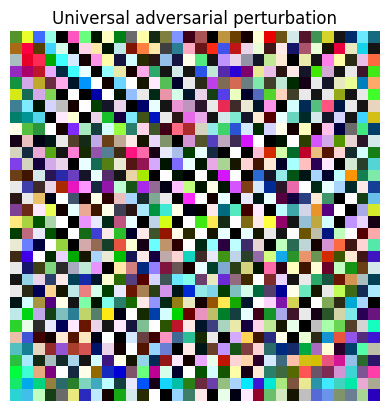

In [102]:
import matplotlib.pyplot as plt

def show_universal_noise(delta):
    noise = delta.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()

    noise_min = noise.min()
    noise_max = noise.max()
    noise_vis = (noise - noise_min) / (noise_max - noise_min + 1e-8)

    plt.imshow(noise_vis)
    plt.title("Universal adversarial perturbation")
    plt.axis("off")
    plt.show()

show_universal_noise(delta)